In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Adjust settings for display
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
# Define the relative path to raw data
DATA_DIR = Path("../data/raw")

# Check whether the folder exists
print(f"Data directory exists: {DATA_DIR.exists()}")

# List available files
for file in DATA_DIR.glob("*.csv"):
    print(file.name)

Data directory exists: True
olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


In [3]:
# Load all datasets into Pandas DataFrames
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
geolocation = pd.read_csv(DATA_DIR / "olist_geolocation_dataset.csv")
order_items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv")
category_translation = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

# Create a dictionary of tables for clean iterations
tables = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation
}

In [4]:
for name, df in tables.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

customers: 99441 rows, 5 columns
geolocation: 1000163 rows, 5 columns
order_items: 112650 rows, 7 columns
payments: 103886 rows, 5 columns
reviews: 99224 rows, 7 columns
orders: 99441 rows, 8 columns
products: 32951 rows, 9 columns
sellers: 3095 rows, 4 columns
category_translation: 71 rows, 2 columns


In [5]:
# Preview a selection of central tables as requested
print("--- Customers Head ---")
display(customers.head())

print("\n--- Orders Head ---")
display(orders.head())

print("\n--- Order Items Head ---")
display(order_items.head())

print("\n--- Products Head ---")
display(products.head())

# Repeat for remaining tables
print("\n--- Remaining Tables Previews ---")
for name, df in tables.items():
    if name not in ["customers", "orders", "order_items", "products"]:
        print(f"\nTable: {name}")
        display(df.head(2))

--- Customers Head ---


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



--- Orders Head ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



--- Order Items Head ---


...

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13



Table: sellers


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP



Table: category_translation


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories


In [6]:
for name, df in tables.items():
    print("\n" + "=" * 80)
    print(name.upper())
    print("=" * 80)
    df.info()


CUSTOMERS
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB

GEOLOCATION
<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 

In [7]:
def summarize_table(name, df):
    return {
        "table_name": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_values": df.isnull().sum().sum(),
        "duplicate_rows": df.duplicated().sum()
    }

summary = pd.DataFrame([
    summarize_table(name, df)
    for name, df in tables.items()
])

# Save this summary to the reports directory
summary.to_csv("../reports/lab01_dataset_summary.csv", index=False)

# Display summary dataframe
summary

,table_name,rows,columns,missing_values,duplicate_rows
0,customers,99441,5,0,0
1,geolocation,1000163,5,0,261831
2,order_items,112650,7,0,0
3,payments,103886,5,0,0
4,reviews,99224,7,145903,0
5,orders,99441,8,4908,0
6,products,32951,9,2448,0
7,sellers,3095,4,0,0
8,category_translation,71,2,0,0


In [8]:
def missing_value_summary(df):
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    result = pd.DataFrame({
        "missing_count": missing_count,
        "missing_percent": missing_percent
    })
    return result[result["missing_count"] > 0].sort_values(
        by="missing_percent",
        ascending=False
    )

# Individual check for orders table
print("Missing values in Orders Table:")
display(missing_value_summary(orders))

print("\nIterating through all tables for missing value breakdowns:")
for name, df in tables.items():
    print("\n" + "=" * 80)
    print(f"Missing Values in {name}")
    print("=" * 80)
    display(missing_value_summary(df))

Missing values in Orders Table:


,missing_count,missing_percent
order_delivered_customer_date,2965,2.981668
order_delivered_carrier_date,1783,1.793023
order_approved_at,160,0.160899



Iterating through all tables for missing value breakdowns:

Missing Values in customers


,missing_count,missing_percent



Missing Values in geolocation


...

,missing_count,missing_percent
product_category_name,610,1.851234
product_name_lenght,610,1.851234
product_description_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_length_cm,2,0.006070
product_height_cm,2,0.006070
product_width_cm,2,0.006070



Missing Values in sellers


,missing_count,missing_percent



Missing Values in category_translation


,missing_count,missing_percent


In [9]:
for name, df in tables.items():
    duplicate_count = df.duplicated().sum()
    print(f"{name}: {duplicate_count} duplicate rows")

customers: 0 duplicate rows
geolocation: 261831 duplicate rows
order_items: 0 duplicate rows
payments: 0 duplicate rows
reviews: 0 duplicate rows
orders: 0 duplicate rows
products: 0 duplicate rows
sellers: 0 duplicate rows
category_translation: 0 duplicate rows


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


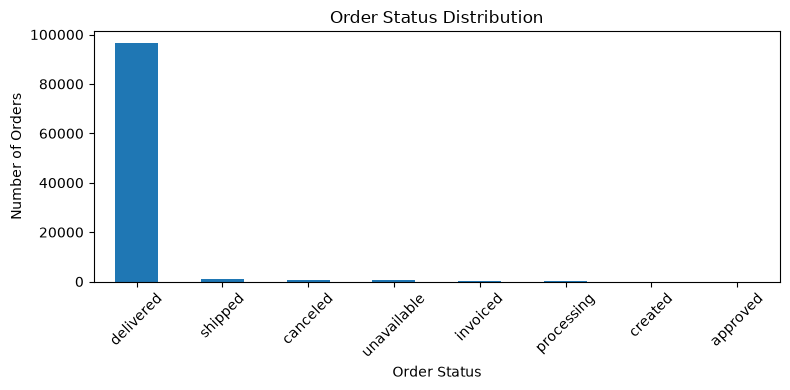

In [10]:
# Preview
display(orders.head())

# Check status distribution
print(orders["order_status"].value_counts())

# Generate, save, and plot the distribution figure
plt.figure(figsize=(8, 4))
orders["order_status"].value_counts().plot(kind="bar")
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()

# Save figure to destination
plt.savefig("../figures/lab01_order_status_distribution.png")
plt.show()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


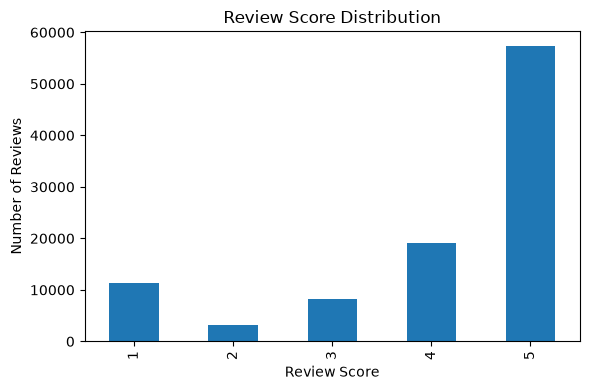

In [11]:
# Preview
display(reviews.head())

# Distribution count
print(reviews["review_score"].value_counts().sort_index())

# Plot distribution
plt.figure(figsize=(6, 4))
reviews["review_score"].value_counts().sort_index().plot(kind="bar")
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


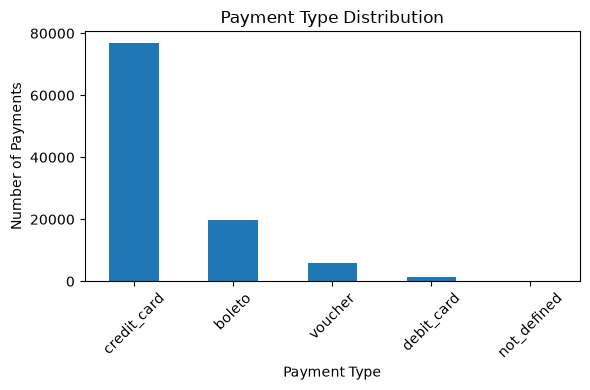

In [12]:
# Preview
display(payments.head())

# Distribution count
print(payments["payment_type"].value_counts())

# Plot distribution
plt.figure(figsize=(6, 4))
payments["payment_type"].value_counts().plot(kind="bar")
plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Payments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Preview
display(products.head())

# Missing value evaluation
print("Missing values in Products:")
display(missing_value_summary(products))

# Category counts
print(f"Unique product categories: {products['product_category_name'].nunique()}")
print("\nTop 10 Product Categories:")
print(products["product_category_name"].value_counts().head(10))

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Missing values in Products:


,missing_count,missing_percent
product_category_name,610,1.851234
product_name_lenght,610,1.851234
product_description_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_length_cm,2,0.006070
product_height_cm,2,0.006070
product_width_cm,2,0.006070


Unique product categories: 73

Top 10 Product Categories:
product_category_name
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: count, dtype: int64


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Top 10 customer states:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64


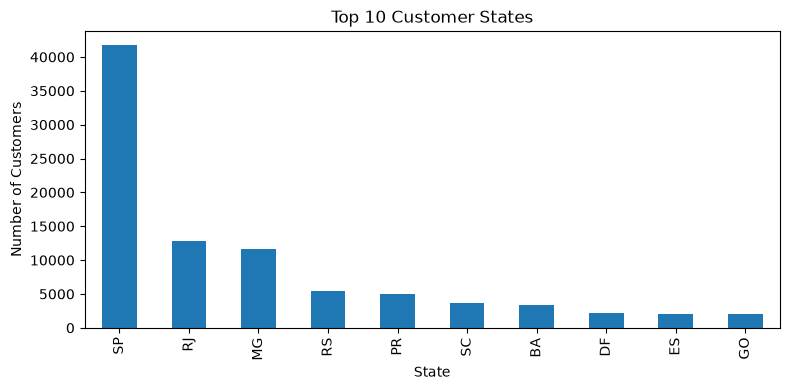

In [14]:
# Preview
display(customers.head())

# Top states distribution
print("Top 10 customer states:")
print(customers["customer_state"].value_counts().head(10))

# Plot top 10 states
plt.figure(figsize=(8, 4))
customers["customer_state"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Customer States")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [15]:
print("Question 1: How many unique customers are present?")
print(customers["customer_unique_id"].nunique())
print("-" * 50)

print("Question 2: How many orders are present?")
print(orders["order_id"].nunique())
print("-" * 50)

print("Question 3: What are the most common order statuses?")
print(orders["order_status"].value_counts())
print("-" * 50)

print("Question 4: What are the most common payment methods?")
print(payments["payment_type"].value_counts())
print("-" * 50)

print("Question 5: What is the average review score?")
print(reviews["review_score"].mean())
print("-" * 50)

print("Question 6: Which states have the most customers?")
print(customers["customer_state"].value_counts().head(10))

Question 1: How many unique customers are present?
96096
--------------------------------------------------
Question 2: How many orders are present?
99441
--------------------------------------------------
Question 3: What are the most common order statuses?
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64
--------------------------------------------------
Question 4: What are the most common payment methods?
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64
--------------------------------------------------
Question 5: What is the average review score?
4.08642062404257
--------------------------------------------------
Question 6: Which states have the most customers?
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     

In [16]:
# Task 18: Identify Potential Machine Learning Problems
import pandas as pd

ml_problems = pd.DataFrame({
    "ML Problem": [
        "Predict late delivery",
        "Predict review score",
        "Predict payment value",
        "Segment customers",
        "Recommend product categories",
        "Detect unusual orders",
        "Forecast monthly sales"
    ],
    "Type": [
        "Classification",
        "Regression/Classification",
        "Regression",
        "Clustering",
        "Recommendation",
        "Anomaly Detection",
        "Time Series Forecasting"
    ],
    "Possible Target": [
        "Late / Not Late",
        "review_score",
        "payment_value",
        "No explicit target",
        "product_category_name",
        "No explicit target",
        "Monthly revenue"
    ]
})

ml_problems

,ML Problem,Type,Possible Target
0,Predict late delivery,Classification,Late / Not Late
1,Predict review score,Regression/Classification,review_score
2,Predict payment value,Regression,payment_value
3,Segment customers,Clustering,No explicit target
4,Recommend product categories,Recommendation,product_category_name
5,Detect unusual orders,Anomaly Detection,No explicit target
6,Forecast monthly sales,Time Series Forecasting,Monthly revenue


In [17]:
# Task 19 : Create Initial Data Dictionary
import pandas as pd
data_dictionary = pd.DataFrame([
    # Customers Table
    ["customers", "customer_id", "String", "Unique customer identifier for each order", "abc123"],
    ["customers", "customer_unique_id", "String", "Unique customer identifier", "861eff4711a542e4b93843c6dd7febb0"],
    ["customers", "customer_zip_code_prefix", "Integer", "Customer ZIP code prefix", "14409"],
    ["customers", "customer_city", "String", "Customer city", "franca"],
    ["customers", "customer_state", "String", "Customer state", "SP"],

    # Orders Table
    ["orders", "order_id", "String", "Unique order identifier", "xyz789"],
    ["orders", "customer_id", "String", "Customer who placed the order", "abc123"],
    ["orders", "order_status", "String", "Current status of the order", "delivered"],
    ["orders", "order_purchase_timestamp", "Datetime", "Order purchase date and time", "2017-10-02 10:56:33"],
    ["orders", "order_approved_at", "Datetime", "Order approval date and time", "2017-10-02 11:07:15"],
    ["orders", "order_delivered_carrier_date", "Datetime", "Date when order was handed to the carrier", "2017-10-04 19:55:00"],
    ["orders", "order_delivered_customer_date", "Datetime", "Date when order was delivered to the customer", "2017-10-10 21:25:13"],
    ["orders", "order_estimated_delivery_date", "Datetime", "Estimated delivery date", "2017-10-18"],

    # Order Items Table
    ["order_items", "order_id", "String", "Order identifier", "xyz789"],
    ["order_items", "order_item_id", "Integer", "Item number within the order", "1"],
    ["order_items", "product_id", "String", "Purchased product identifier", "prod123"],
    ["order_items", "seller_id", "String", "Seller identifier", "seller567"],
    ["order_items", "shipping_limit_date", "Datetime", "Last date for shipping the product", "2017-09-19 09:45:35"],
    ["order_items", "price", "Float", "Price of the product", "58.90"],
    ["order_items", "freight_value", "Float", "Shipping cost", "13.29"]
], columns=[
    "Table",
    "Column",
    "Data Type",
    "Description",
    "Example Value"
])

data_dictionary

,Table,Column,Data Type,Description,Example Value
0,customers,customer_id,String,Unique customer identifier for each order,abc123
1,customers,customer_unique_id,String,Unique customer identifier,861eff4711a542e4b93843c6dd7febb0
2,customers,customer_zip_code_prefix,Integer,Customer ZIP code prefix,14409
3,customers,customer_city,String,Customer city,franca
4,customers,customer_state,String,Customer state,SP
5,orders,order_id,String,Unique order identifier,xyz789
6,orders,customer_id,String,Customer who placed the order,abc123
7,orders,order_status,String,Current status of the order,delivered
8,orders,order_purchase_timestamp,Datetime,Order purchase date and time,2017-10-02 10:56:33
9,orders,order_approved_at,Datetime,Order approval date and time,2017-10-02 11:07:15


In [18]:
from pathlib import Path

Path(r"C:\Environment\MachineLearning2026\README.md").touch(exist_ok=True)

print("README.md created successfully!")

README.md created successfully!


1. Why is it important to understand the dataset before building a Machine Learning model?

Understanding the dataset helps identify the data structure, features, missing values, data types, relationships between tables, and potential issues. This enables proper data preprocessing, feature selection, and model building, leading to more accurate and reliable predictions.

2. Which table appears to be the central table in the Olist dataset? Why?

The orders table is the central table because it connects to several other tables using keys such as order_id and customer_id. It acts as the main hub linking customers, products, payments, reviews, and deliveries.

3. What is the difference between customer_id and customer_unique_id?
customer_id: A unique identifier for each order record. A customer may have different customer_ids if they place multiple orders.
customer_unique_id: A permanent identifier for the actual customer. It remains the same across all orders placed by that customer.
4. Which columns appear to represent dates?

Examples include:

order_purchase_timestamp
order_approved_at
order_delivered_carrier_date
order_delivered_customer_date
order_estimated_delivery_date
shipping_limit_date
review_creation_date
review_answer_timestamp
5. Which columns appear to represent categorical variables?

Examples include:

order_status
payment_type
customer_city
customer_state
seller_city
seller_state
product_category_name
review_score
customer_zip_code_prefix
seller_zip_code_prefix
6. Which columns contain missing values?

Common columns with missing values are:

order_approved_at
order_delivered_carrier_date
order_delivered_customer_date
product_category_name
product_name_lenght
product_description_lenght
product_photos_qty
product_weight_g
product_length_cm
product_height_cm
product_width_cm
7. Which tables can be joined using order_id?

The following tables can be joined using order_id:

orders
order_items
order_payments
order_reviews
8. Which tables can be joined using product_id?

The following tables can be joined using product_id:

order_items
products
9. What are three potential Machine Learning problems that can be created from this dataset?
Delivery Time Prediction – Predict how long an order will take to be delivered.
Customer Review Score Prediction – Predict the rating (1–5 stars) a customer is likely to give.
Sales Forecasting/Product Demand Prediction – Predict future product sales based on historical purchase data.
10. What ethical concerns may arise when using customer data for ML?

Some ethical concerns include:

Protecting customer privacy and personal information.
Preventing unauthorized access or data breaches.
Avoiding bias and unfair predictions.
Obtaining proper user consent for data usage.
Ensuring compliance with data protection laws and regulations.
Maintaining transparency in how customer data is used.

